In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import argparse
import bokeh.plotting as bkp
from bokeh.models import ColumnDataSource, HoverTool    
from bokeh.io import output_file, save  
from bokeh.layouts import gridplot
from bokeh.transform import factor_cmap
from bokeh.palettes import Category20_20    
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import sys
import subprocess
import pkgutil
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
import IPython.display as display   
from ipywidgets import interact, interactive, fixed, interact_manual, widgets
import nbformat

#### plot settings

In [5]:
%matplotlib inline
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 160)

print('setup complete.')

setup complete.


### Reading Data

In [6]:
csv_path = 'https://raw.githubusercontent.com/JoeBornrich/code-umbrella/refs/heads/main/DA%20%26%20VISUALIZATION/sales_data.csv'
try:
    sales_data = pd.read_csv(csv_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file at {csv_path} was not found.")

Data loaded successfully.


In [7]:
sales_data.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [8]:
sales_data.shape

(113036, 18)

In [9]:
sales_data.dtypes

Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object

In [10]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [11]:
sales_data.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [12]:
print('Shape:', sales_data.shape)
print('\nColumns:')
for i, c in enumerate(sales_data.columns):
   print(i+1, c)

Shape: (113036, 18)

Columns:
1 Date
2 Day
3 Month
4 Year
5 Customer_Age
6 Age_Group
7 Customer_Gender
8 Country
9 State
10 Product_Category
11 Sub_Category
12 Product
13 Order_Quantity
14 Unit_Cost
15 Unit_Price
16 Profit
17 Cost
18 Revenue


In [15]:
print('\nMissing values per column:')
display.display(sales_data.isna().sum().sort_values(ascending=False))


Missing values per column:


Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

In [16]:
print('\nDuplicate rows (full row duplicates):', sales_data.duplicated().sum())
print('\nBasic numeric summary:')
display.display(sales_data.describe(include=[np.number]).T)

print('\nBasic object / category summary:')
display.display(sales_data.describe(include=['object', 'category']).T)


Duplicate rows (full row duplicates): 1000

Basic numeric summary:


,count,mean,std,min,25%,50%,75%,max
Day,113036.0,15.665753,8.781567,1.0,8.0,16.0,23.0,31.0
Year,113036.0,2014.401739,1.272510,2011.0,2013.0,2014.0,2016.0,2016.0
Customer_Age,113036.0,35.919212,11.021936,17.0,28.0,35.0,43.0,87.0
Order_Quantity,113036.0,11.901660,9.561857,1.0,2.0,10.0,20.0,32.0
Unit_Cost,113036.0,267.296366,549.835483,1.0,2.0,9.0,42.0,2171.0
Unit_Price,113036.0,452.938427,922.071219,2.0,5.0,24.0,70.0,3578.0
Profit,113036.0,285.051665,453.887443,-30.0,29.0,101.0,358.0,15096.0
Cost,113036.0,469.318695,884.866118,1.0,28.0,108.0,432.0,42978.0
Revenue,113036.0,754.370360,1309.094674,2.0,63.0,223.0,800.0,58074.0



Basic object / category summary:


,count,unique,top,freq
Date,113036,1884,2016-03-01,288
Month,113036,12,June,11234
Age_Group,113036,4,Adults (35-64),55824
Customer_Gender,113036,2,M,58312
Country,113036,6,United States,39206
State,113036,53,California,22450
Product_Category,113036,3,Accessories,70120
Sub_Category,113036,17,Tires and Tubes,33870
Product,113036,130,Water Bottle - 30 oz.,10794


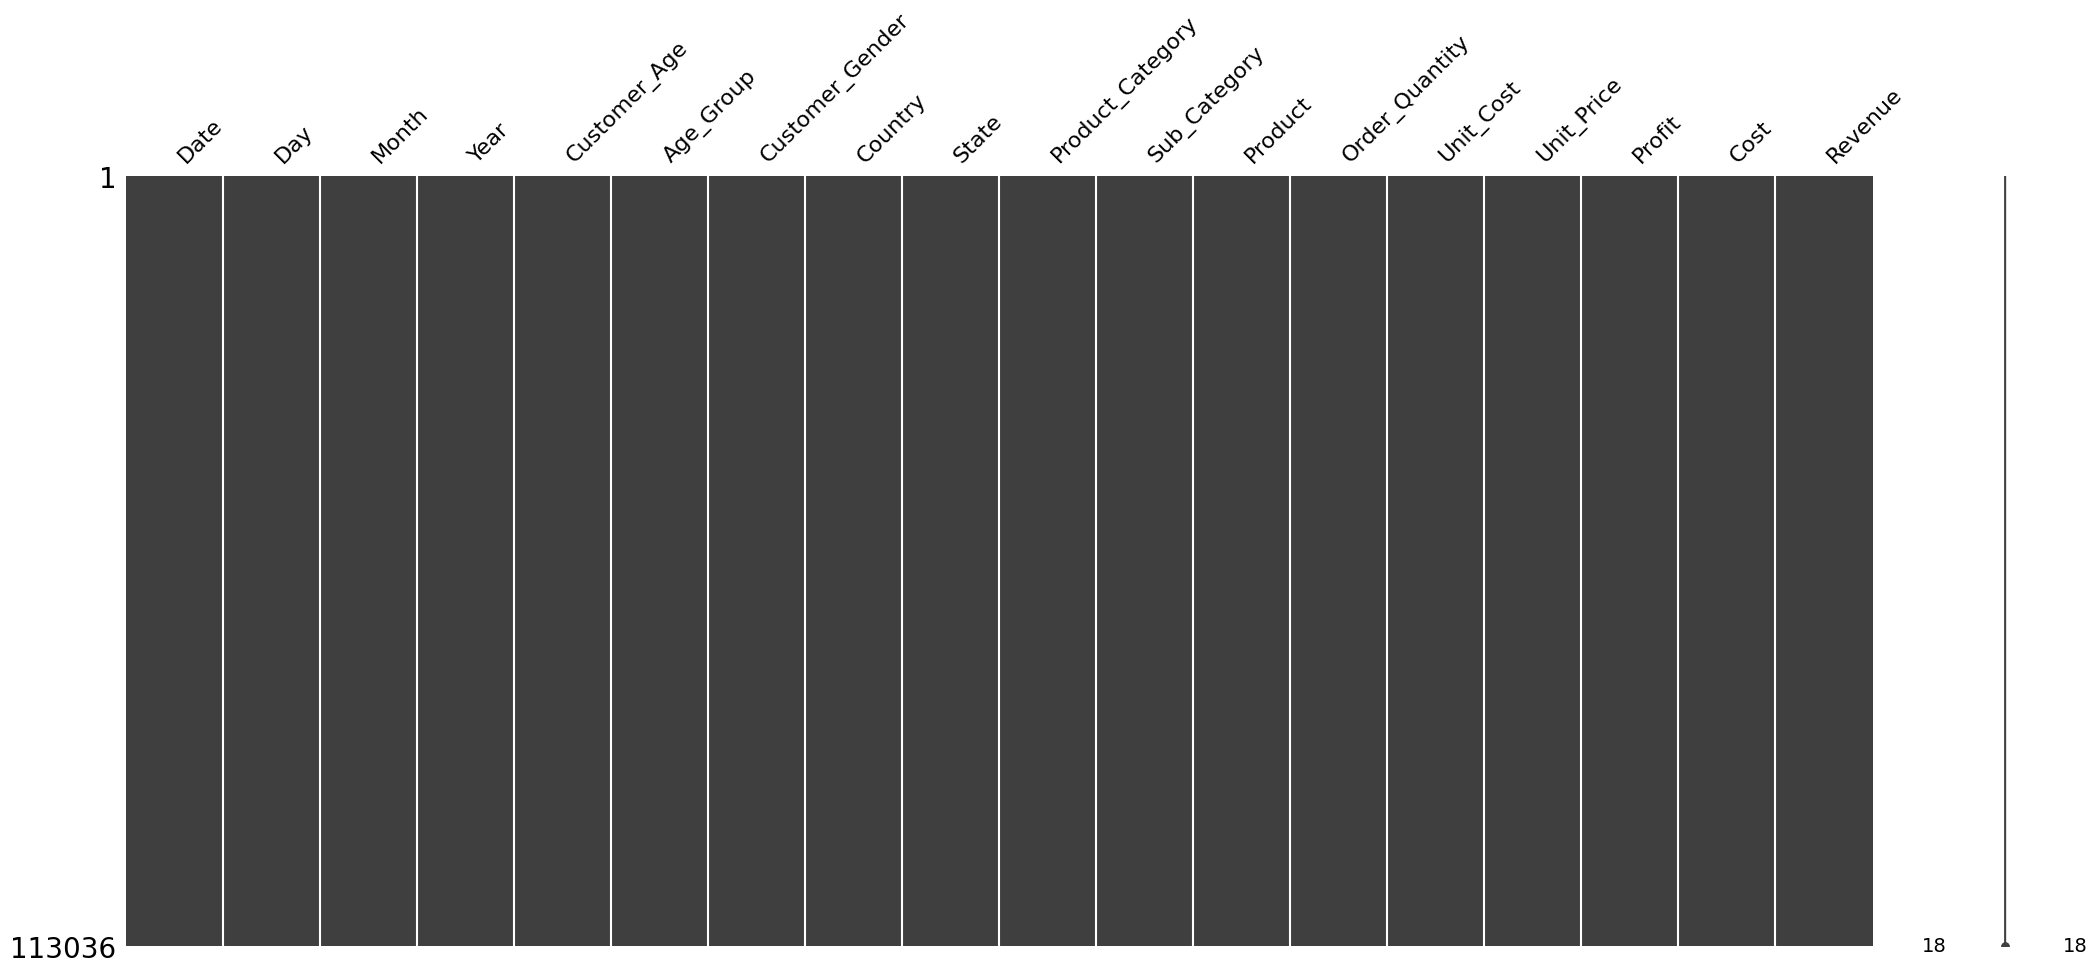

In [17]:
try:
   msno.matrix(sales_data)
   plt.show()
except Exception as e:
   print('missingno visualization failed:', e)

## Datatype Correction

In [18]:
possible_date_cols = []
for col in sales_data.columns:
 if sales_data[col].dtype == 'object':
    sample = sales_data[col].dropna().astype(str).head(20).to_list()
# crude checks for date-like content
if any(['-' in s or '/' in s or ':' in s for s in sample]):
     possible_date_cols.append(col)


print('Possible date-like columns:', possible_date_cols)

Possible date-like columns: ['Revenue']


In [19]:
for col in possible_date_cols:
    try:
        converted = pd.to_datetime(sales_data[col], errors='coerce', dayfirst=True)
        if converted.notna().sum() > 0:
            sales_data[col + '_parsed'] = converted
            print(f'Parsed {col} into {col + "_parsed"} — non-null count: {converted.notna().sum()}')
    except Exception as e:
        print('Failed to parse', col, e)

Parsed Revenue into Revenue_parsed — non-null count: 113036


In [20]:
sales_data.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Revenue_parsed
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,1970-01-01 00:00:00.000000950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,1970-01-01 00:00:00.000000950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401,1970-01-01 00:00:00.000002401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088,1970-01-01 00:00:00.000002088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418,1970-01-01 00:00:00.000000418


In [21]:
sales_data.tail()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Revenue_parsed
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184,1970-01-01 00:00:00.000000184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183,1970-01-01 00:00:00.000001183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183,1970-01-01 00:00:00.000001183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260,1970-01-01 00:00:00.000001260
113035,2016-03-04,4,March,2016,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",23,24,64,655,552,1207,1970-01-01 00:00:00.000001207


In [22]:
for col in sales_data.select_dtypes(include=['object']).columns:
	# skip columns that we already parsed to dates
	if col + '_parsed' in sales_data.columns:
		continue
	coerced = pd.to_numeric(
		sales_data[col].str.replace(',', '').str.replace('£', '').str.strip(),
		errors='coerce'
	) if sales_data[col].dtype == 'object' else None
	if coerced is not None and coerced.notna().sum() > 0:
		non_null = coerced.notna().sum()
		pct = non_null / len(sales_data)
		if pct > 0.1:  # heuristics: only create if >10% convertible
			sales_data[col + '_num'] = coerced
			print(f'Coerced {col} to numeric column {col + "_num"} — converted {non_null} rows ({pct:.0%})')

print('\nData types after parsing:')
print(sales_data.dtypes)


Data types after parsing:
Date                        object
Day                          int64
Month                       object
Year                         int64
Customer_Age                 int64
Age_Group                   object
Customer_Gender             object
Country                     object
State                       object
Product_Category            object
Sub_Category                object
Product                     object
Order_Quantity               int64
Unit_Cost                    int64
Unit_Price                   int64
Profit                       int64
Cost                         int64
Revenue                      int64
Revenue_parsed      datetime64[ns]
dtype: object


### Duplicate handling

In [23]:
dup_mask = sales_data.duplicated(keep=False)
print('Total duplicated rows (keep=False):', dup_mask.sum())
if dup_mask.sum() > 0:
	display.display(sales_data[dup_mask].head(10))


# Missing values: show columns with >0 missing and percentage
missing = sales_data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
	missing_pct = (missing / len(sales_data) * 100).round(2)
	display.display(pd.concat([missing, missing_pct.rename('pct')], axis=1))
else:
	print('No missing values detected.')

Total duplicated rows (keep=False): 1993


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Revenue_parsed
1020,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245,1970-01-01 00:00:00.000001245
1021,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245,1970-01-01 00:00:00.000001245
1090,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40,1970-01-01 00:00:00.000000040
1091,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40,1970-01-01 00:00:00.000000040
1092,2013-10-24,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16,1970-01-01 00:00:00.000000016
1093,2013-10-24,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16,1970-01-01 00:00:00.000000016
1094,2015-10-24,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8,1970-01-01 00:00:00.000000008
1095,2015-10-24,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8,1970-01-01 00:00:00.000000008
1192,2016-01-15,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57,1970-01-01 00:00:00.000000057
1193,2016-01-15,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57,1970-01-01 00:00:00.000000057


No missing values detected.


In [24]:
cleaned = sales_data.copy()

In [25]:
imputation_log = {}
for col in cleaned.columns:
	if cleaned[col].isna().sum() == 0:
		continue
	if np.issubdtype(cleaned[col].dtype, np.number):
		med = cleaned[col].median()
		cleaned[col] = cleaned[col].fillna(med)
		imputation_log[col] = ('median', med)
	else:
		mode = cleaned[col].mode()
		if not mode.empty:
			val = mode[0]
			cleaned[col] = cleaned[col].fillna(val)
			imputation_log[col] = ('mode', val)
		else:
			cleaned[col] = cleaned[col].fillna('missing')
			imputation_log[col] = ('filled_with_string', 'missing')

print('Imputation log:')
for k, v in imputation_log.items():
	print(k, v)

Imputation log:


In [26]:
if 'Quantity' in cleaned.columns and 'UnitPrice' in cleaned.columns:
	cleaned['TotalPrice'] = cleaned['Quantity'] * cleaned['UnitPrice']
	print('Created TotalPrice = Quantity * UnitPrice')

# If we parsed a date column earlier, extract components
for col in cleaned.columns:
	if col.endswith('_parsed'):
		cleaned[col + '_year'] = cleaned[col].dt.year
		cleaned[col + '_month'] = cleaned[col].dt.month
		cleaned[col + '_day'] = cleaned[col].dt.day
		print('Extracted year/month/day from', col)

Extracted year/month/day from Revenue_parsed


In [27]:
for col in cleaned.select_dtypes(include=['object']).columns:
	if cleaned[col].nunique() < 100:
		cleaned[col] = cleaned[col].astype('category')

print('\nSample of cleaned data:')
display.display(cleaned.head())


Sample of cleaned data:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Revenue_parsed,Revenue_parsed_year,Revenue_parsed_month,Revenue_parsed_day
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,1970-01-01 00:00:00.000000950,1970,1,1
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,1970-01-01 00:00:00.000000950,1970,1,1
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401,1970-01-01 00:00:00.000002401,1970,1,1
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088,1970-01-01 00:00:00.000002088,1970,1,1
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418,1970-01-01 00:00:00.000000418,1970,1,1


## Exploratory Data Analysis

Numeric columns: ['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue', 'Revenue_parsed_year', 'Revenue_parsed_month', 'Revenue_parsed_day']


,count,mean,std,min,25%,50%,75%,max
Day,113036.0,15.665753,8.781567,1.0,8.0,16.0,23.0,31.0
Year,113036.0,2014.401739,1.272510,2011.0,2013.0,2014.0,2016.0,2016.0
Customer_Age,113036.0,35.919212,11.021936,17.0,28.0,35.0,43.0,87.0
Order_Quantity,113036.0,11.901660,9.561857,1.0,2.0,10.0,20.0,32.0
Unit_Cost,113036.0,267.296366,549.835483,1.0,2.0,9.0,42.0,2171.0
Unit_Price,113036.0,452.938427,922.071219,2.0,5.0,24.0,70.0,3578.0
Profit,113036.0,285.051665,453.887443,-30.0,29.0,101.0,358.0,15096.0
Cost,113036.0,469.318695,884.866118,1.0,28.0,108.0,432.0,42978.0
Revenue,113036.0,754.370360,1309.094674,2.0,63.0,223.0,800.0,58074.0
Revenue_parsed_year,113036.0,1970.000000,0.000000,1970.0,1970.0,1970.0,1970.0,1970.0


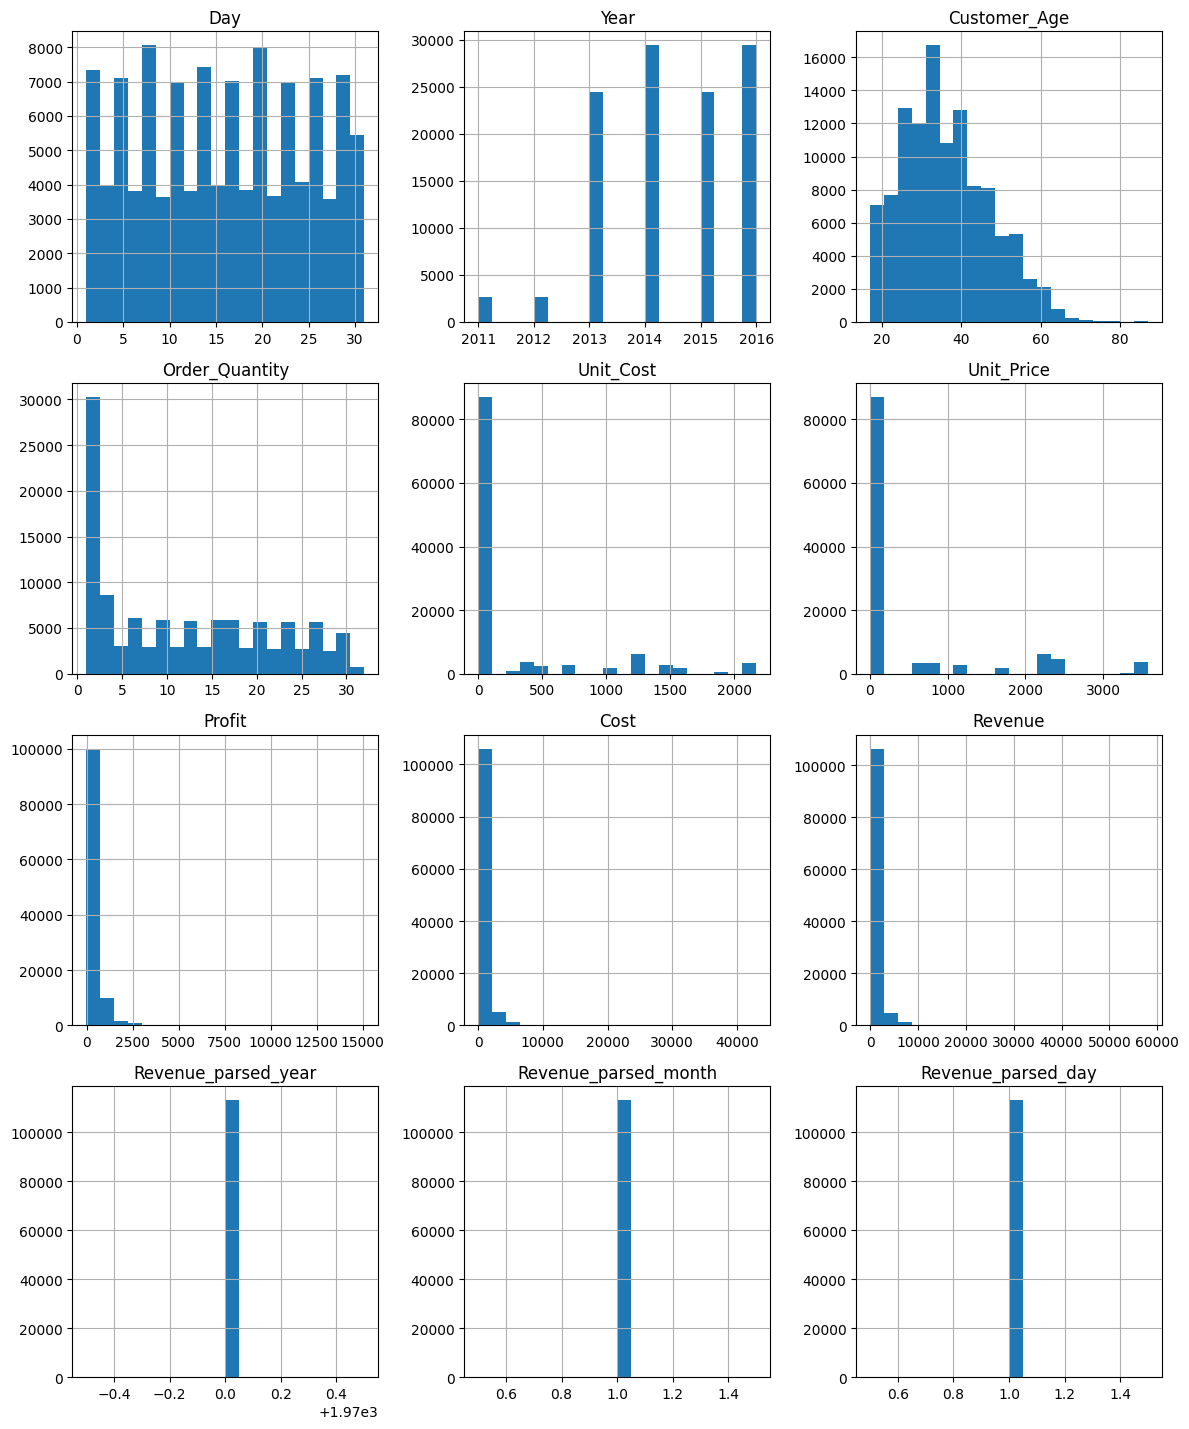

In [28]:
num_cols = cleaned.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)

if num_cols:
	display.display(cleaned[num_cols].describe().T)
	# quick histograms
	cleaned[num_cols].hist(bins=20, figsize=(12, max(4, len(num_cols)*1.2)))
	plt.tight_layout()

Categorical columns (top 10 unique shown):
-> Date: 1884 unique values


Date
2016-03-01    288
2014-03-01    288
2015-12-07    241
2013-12-07    241
2016-06-14    236
2014-06-14    236
2016-02-20    221
2014-02-20    221
2016-04-03    218
2014-04-03    218
Name: count, dtype: int64

-> Month: 12 unique values


Month
June        11234
December    11200
May         11128
April       10182
March        9674
January      9284
February     9022
October      8750
November     8734
August       8200
Name: count, dtype: int64

-> Age_Group: 4 unique values


...

Product_Category
Accessories    70120
Bikes          25982
Clothing       16934
Name: count, dtype: int64

-> Sub_Category: 17 unique values


Sub_Category
Tires and Tubes      33870
Bottles and Cages    15876
Road Bikes           13430
Helmets              12158
Mountain Bikes        8854
Jerseys               6010
Caps                  4358
Fenders               4032
Touring Bikes         3698
Gloves                2686
Name: count, dtype: int64

-> Product: 130 unique values


Product
Water Bottle - 30 oz.      10794
Patch Kit/8 Patches        10416
Mountain Tire Tube          6816
AWC Logo Cap                4358
Sport-100 Helmet, Red       4220
Road Tire Tube              4176
Sport-100 Helmet, Black     4152
Fender Set - Mountain       4032
Sport-100 Helmet, Blue      3788
Touring Tire Tube           3702
Name: count, dtype: int64

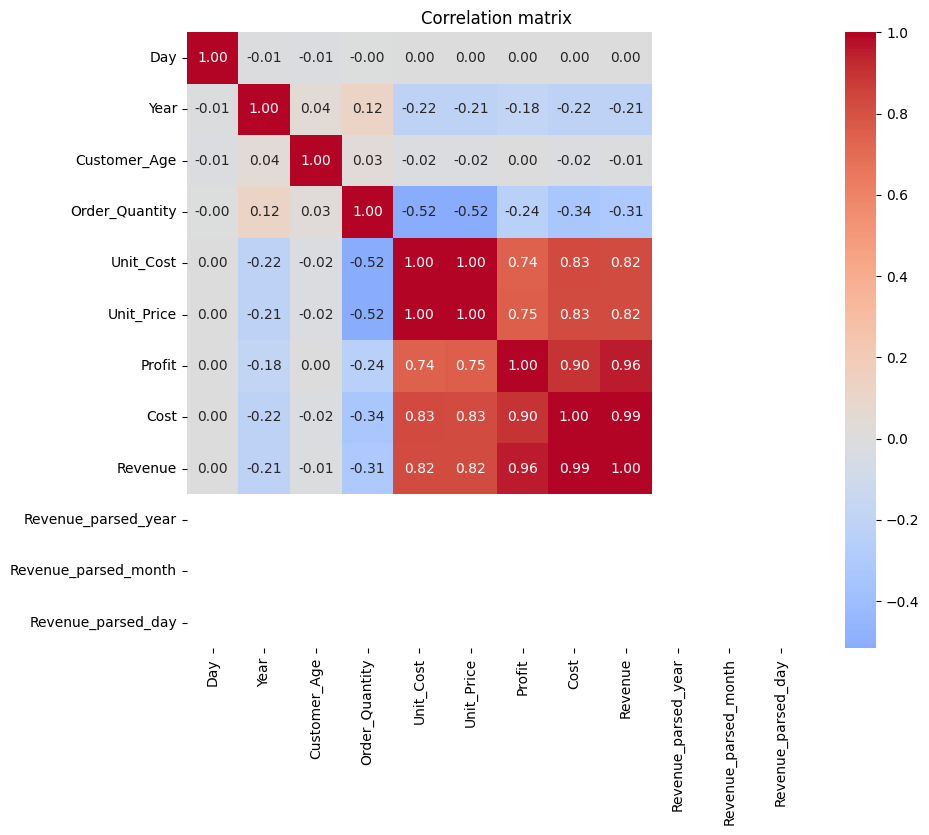

In [29]:
cat_cols = cleaned.select_dtypes(include=['category', 'object']).columns.tolist()
print('Categorical columns (top 10 unique shown):')
for c in cat_cols:
	print(f'-> {c}: {cleaned[c].nunique()} unique values')
	display.display(cleaned[c].value_counts().head(10))


# Correlation heatmap
if len(num_cols) >= 2:
	corr = cleaned[num_cols].corr()
	plt.figure(figsize=(10,8))
	sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
	plt.title('Correlation matrix')

In [30]:
datetime_cols = [c for c in cleaned.columns if c.endswith('_parsed') and pd.api.types.is_datetime64_any_dtype(cleaned[c])]
print('Detected datetime columns:', datetime_cols)


# Interactive: Time series of TotalPrice if exists
if 'TotalPrice' in cleaned.columns and datetime_cols:
 dt_col = datetime_cols[0]
 ts = cleaned.groupby(pd.Grouper(key=dt_col, freq='D'))['TotalPrice'].sum().reset_index()
 fig = px.line(ts, x=dt_col, y='TotalPrice', title='Daily Total Price')
 fig.update_layout(xaxis_title='Date', yaxis_title='Total Sales')
 fig.show()

Detected datetime columns: ['Revenue_parsed']


In [34]:
# Ensure the output directory exists
output_dir = 'JoeBornrich/code-umbrella/DA & VISUALIZATION'
os.makedirs(output_dir, exist_ok=True)

out_csv = os.path.join(output_dir, 'sales_data_cleaned.csv')
out_xlsx = os.path.join(output_dir, 'sales_data_cleaned.xlsx')
cleaned.to_csv(out_csv, index=False)
try:
	cleaned.to_excel(out_xlsx, index=False)
except Exception as e:
	print('Could not write Excel file (openpyxl needed?):', e)

print('Cleaned data saved to:', out_csv)

Cleaned data saved to: JoeBornrich/code-umbrella/DA & VISUALIZATION\sales_data_cleaned.csv


In [35]:
cleaned.to_csv('sales_data_cleaned.csv', index=False)